# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [58]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [59]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('../data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="../data/GSE139307.pkl")

# TODO: Inspect dataset shapes and missing values
# TODO: Print basic summary statistics for each dataset
print('===X_clf Shape===')
print(X_clf.shape)
print('===y_clf Shape===')
print(y_clf.shape)

print('===X_clf Missing Vals===')
print(X_clf.isna().sum())
print('===y_clf Missing Vals===')
print(y_clf.isna().sum())

print('===X_clf Repeated Rows===')
print(X_clf.duplicated().sum())
print('===y_clf Repeated Rows===')
print(y_clf.duplicated().sum())

print('===X_clf Summary Stats===')
print(X_clf.describe)
print('===y_clf Summary Stats===')
print(y_clf.describe)

duplicated = X_clf.duplicated()
X_clf = X_clf[~duplicated]
y_clf = y_clf[~duplicated]

print('===X_clf Removed Repeated Rows===')
print(X_clf.duplicated().sum())
print('===y_clf Removed Repeated Rows===')
print(y_clf.duplicated().sum())

print('===df_aging Shape===')
print(df_aging.shape)

print('===df_aging Missing Vals===')
print(df_aging.isna().sum().sum())

print('===df_aging Repeated Rows===')
print(df_aging.duplicated().sum())

print('===df_aging Summary Stats===')
print(df_aging.describe)


Successfully loaded heart disease data with 1025 rows


/Users/mprenovitz/Documents/MLinBio/homework-3-mprenovitz/src/hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


===X_clf Shape===
(1025, 13)
===y_clf Shape===
(1025,)
===X_clf Missing Vals===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
===y_clf Missing Vals===
0
===X_clf Repeated Rows===
723
===y_clf Repeated Rows===
1023
===X_clf Summary Stats===
<bound method NDFrame.describe of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    

## Classification Task (Heart Disease)

Exploring classification dataset...


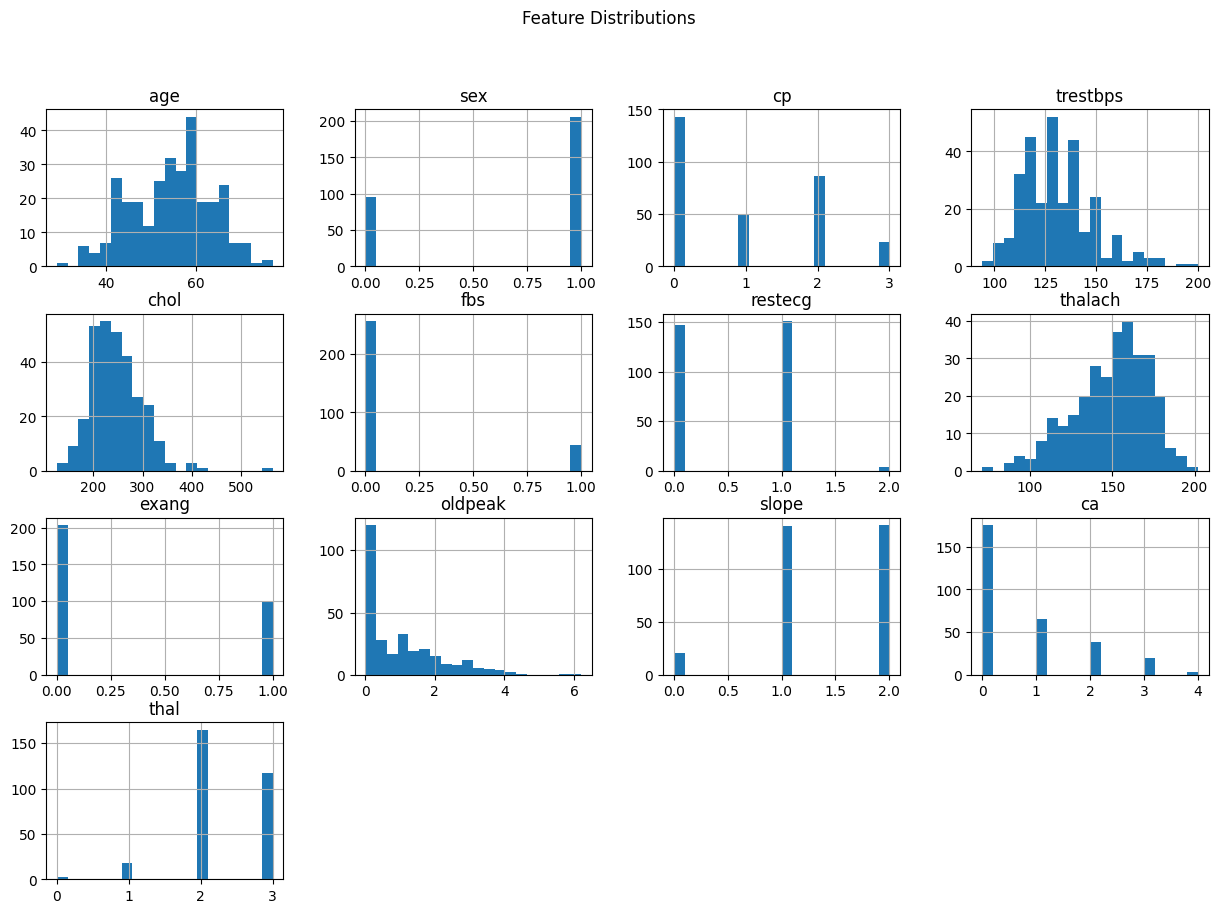

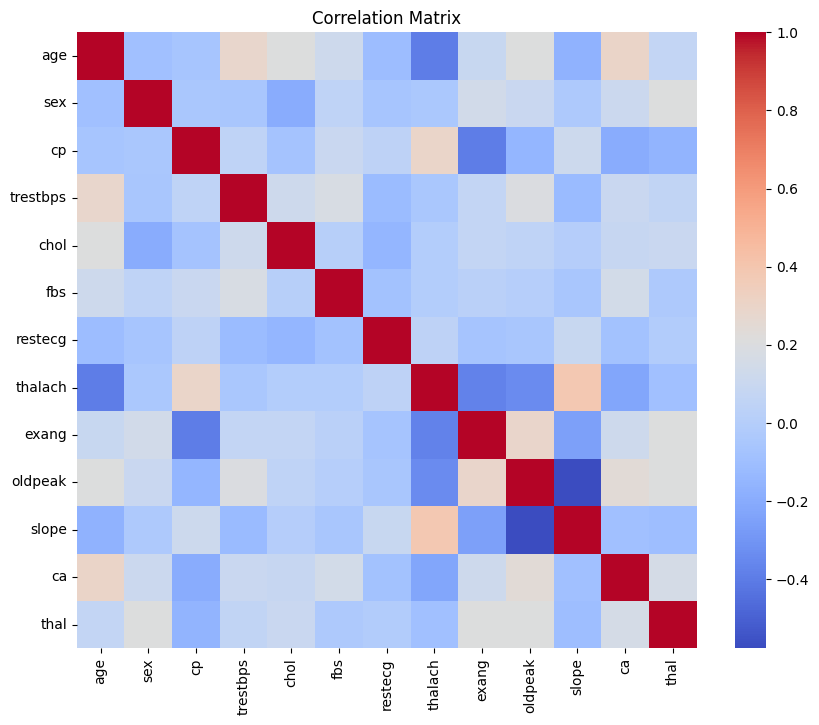

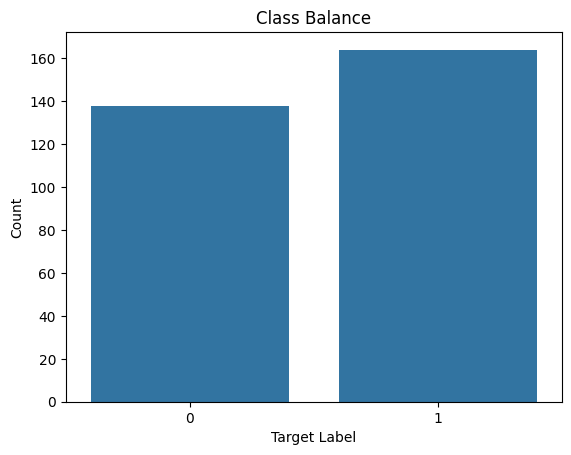

In [60]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils
explore_classification_data(X_clf, y_clf)

In [61]:
# TODO: Split X_clf and y_clf into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, train_size=0.8, random_state=42)

### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [62]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_classifier(kernel=..., C=..., degree=..., gamma=...)),
# ])
#best vals: 
# kernel           poly
# C               0.001
# Degree              3
# Gamma               1
#TODO: fine out if you need imputer and pca
pipeline = Pipeline([
    # ("imputer", ),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_classifier(kernel="poly", C=0.001, degree=3, gamma=1)),
])

### Kernel Experiments

In [63]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
C_values = [0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100, 'auto', 'scale']
degree_values = [1, 2, 3, 4]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

res = []
for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            lin = svm_classifier("linear", c, degree, gamma).fit(X_train_scaled, y_train)
            poly = svm_classifier("poly", c, degree, gamma).fit(X_train_scaled, y_train)
            rbf = svm_classifier("rbf", c, degree, gamma).fit(X_train_scaled, y_train)
            
            lin_metrics = evaluate_classifier(lin, X_test_scaled, y_test)
            poly_metrics = evaluate_classifier(poly, X_test_scaled, y_test)
            rbf_metrics = evaluate_classifier(rbf, X_test_scaled, y_test)

            res.append({
                'kernel': "linear", 
                'C': c, ''
                'Degree': degree, 
                'Gamma': gamma, 
                'Accuracy': lin_metrics['accuracy'], 
                'Precision': lin_metrics['precision'], 
                'Recall': lin_metrics['recall'],
                'F1': lin_metrics['f1']
                })
            res.append({
                'kernel': "poly", 
                'C': c, 
                'Degree': degree, 
                'Gamma': gamma, 
                'Accuracy': poly_metrics['accuracy'], 
                'Precision': poly_metrics['precision'], 
                'Recall': poly_metrics['recall'],
                'F1': poly_metrics['f1']})
            res.append({
                'kernel': "rbf", 
                'C': c, 
                'Degree': degree, 
                'Gamma': gamma, 
                'Accuracy': rbf_metrics['accuracy'], 
                'Precision': rbf_metrics['precision'], 
                'Recall': rbf_metrics['recall'],
                'F1': rbf_metrics['f1']
            })
                

In [64]:
#comparing metrics in a seperate code block so I don't have to rerun everytime.
# Compare kernels and select best model
kernels_df = pd.DataFrame(res)

print('===Max Value for Each Metric for Linear Kernel===')
print('Accuracy:')
lin_res = kernels_df[kernels_df['kernel'] == 'linear']
print(lin_res.loc[lin_res['Accuracy'].idxmax()])
print('Precision:')
print(lin_res.loc[lin_res['Precision'].idxmax()])
print('Recall:')
print(lin_res.loc[lin_res['Recall'].idxmax()])
print('F1:')
print(lin_res.loc[lin_res['F1'].idxmax()])

print('===Max Value for Each Metric for Poly Kernel===')
print('Accuracy:')
poly_res = kernels_df[kernels_df['kernel'] == 'poly']
print(poly_res.loc[poly_res['Accuracy'].idxmax()])
print('Precision:')
print(poly_res.loc[poly_res['Precision'].idxmax()])
print('Recall:')
print(poly_res.loc[poly_res['Recall'].idxmax()])
print('F1:')
print(poly_res.loc[poly_res['F1'].idxmax()])

print('===Max Value for Each Metric for rbf Kernel===')
print('Accuracy:')
rbf_res = kernels_df[kernels_df['kernel'] == 'rbf']
print(rbf_res.loc[rbf_res['Accuracy'].idxmax()])
print('Precision:')
print(rbf_res.loc[rbf_res['Precision'].idxmax()])
print('Recall:')
print(rbf_res.loc[rbf_res['Recall'].idxmax()])
print('F1:')
print(rbf_res.loc[rbf_res['F1'].idxmax()])
#once we have the best combination of hyperparameters we now pass that into our pipeline


===Max Value for Each Metric for Linear Kernel===
Accuracy:
kernel         linear
C                0.01
Degree              1
Gamma           0.001
Accuracy     0.803279
Precision     0.72973
Recall       0.931034
F1           0.818182
Name: 144, dtype: object
Precision:
kernel         linear
C                0.01
Degree              1
Gamma           0.001
Accuracy     0.803279
Precision     0.72973
Recall       0.931034
F1           0.818182
Name: 144, dtype: object
Recall:
kernel         linear
C               0.001
Degree              1
Gamma           0.001
Accuracy     0.508197
Precision    0.491525
Recall            1.0
F1           0.659091
Name: 0, dtype: object
F1:
kernel         linear
C                0.01
Degree              1
Gamma           0.001
Accuracy     0.803279
Precision     0.72973
Recall       0.931034
F1           0.818182
Name: 144, dtype: object
===Max Value for Each Metric for Poly Kernel===
Accuracy:
kernel           poly
C               0.001
Degree       

### Classification Metrics and Visuals

{'accuracy': 0.8360655737704918, 'precision': 0.7878787878787878, 'recall': 0.896551724137931, 'f1': 0.8387096774193549}


Text(0, 0.5, 'y_true')

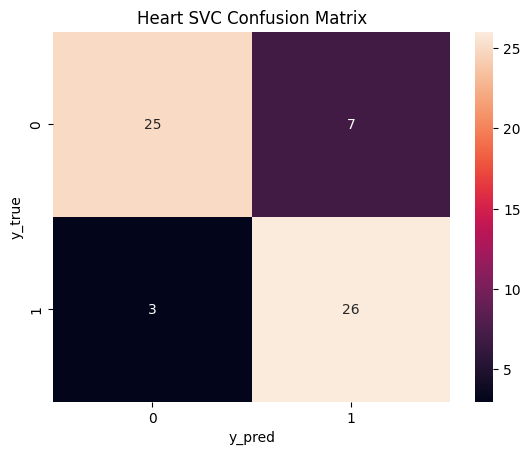

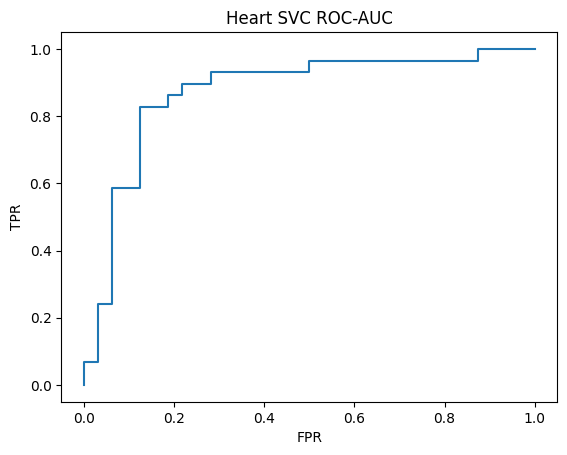

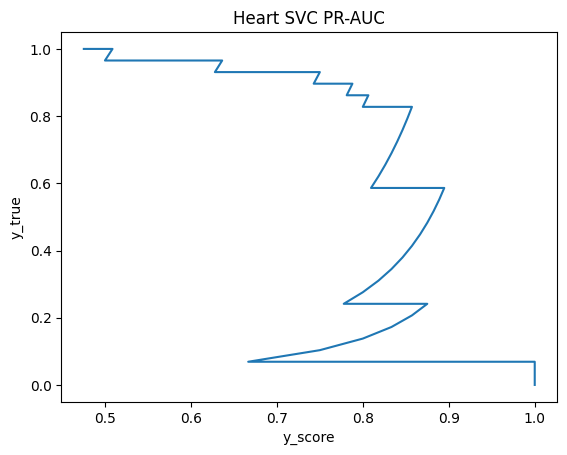

In [65]:
#ASK IF THIS IS GOOD
pipeline.fit(X_train, y_train)
# TODO: Compute accuracy and F1
metrics = evaluate_classifier(pipeline['model'], X_test_scaled, y_test) #ASK AOUT THIS PART
print(metrics) 

decision_func = pipeline.decision_function(X_test)
# TODO: Compute ROC-AUC or PR-AUC
roc_auc = roc_curve(y_test, decision_func)
pr_auc = precision_recall_curve(y_test, decision_func)
# TODO: Plot confusion matrix and ROC/PR curve
plt.figure()
sns.heatmap(confusion_matrix(y_true=y_test, y_pred=pipeline.predict(X_test)), annot=True)
plt.title('Heart SVC Confusion Matrix')
plt.xlabel('y_pred')
plt.ylabel('y_true')


plt.figure()
roc_fpr, roc_tpr, _ = roc_auc
plt.plot(roc_fpr, roc_tpr)
plt.title('Heart SVC ROC-AUC')
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.figure()
pr_fpr, pr_tpr, _ = pr_auc
plt.plot(pr_fpr, pr_tpr)
plt.title('Heart SVC PR-AUC')
plt.xlabel('y_score')
plt.ylabel('y_true')



### Hyperparameter Sensitivity

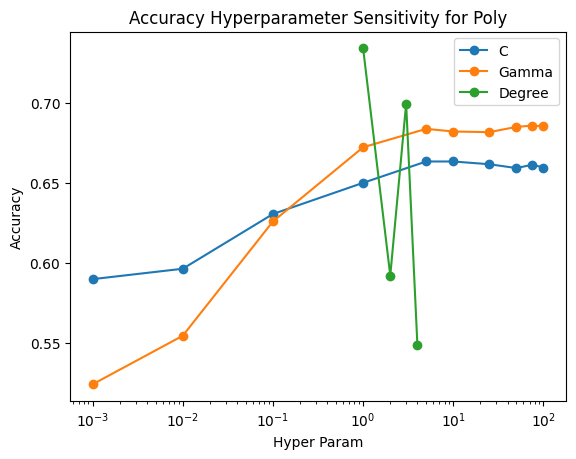

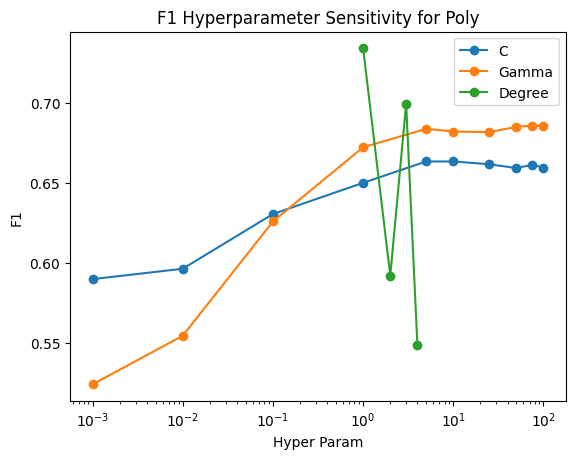

In [66]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel
poly_res = kernels_df[kernels_df['kernel'] == 'poly']
poly_numeric_gamma = poly_res[(poly_res['Gamma'] != 'auto') & (poly_res['Gamma'] != 'scale')]

fig, ax = plt.subplots()
ax.plot(poly_res.groupby('C')['Accuracy'].mean(), marker='o', label='C')
ax.plot(poly_numeric_gamma.groupby('Gamma')['Accuracy'].mean(), marker='o', label='Gamma')
ax.plot(poly_res.groupby('Degree')['Accuracy'].mean(), marker='o', label='Degree')
ax.set_xlabel('Hyper Param')
ax.set_ylabel('Accuracy')
ax.set_xticks([0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100])
ax.set_xscale('log')
ax.set_title('Accuracy Hyperparameter Sensitivity for Poly')
ax.legend()

plt.show()

fig, ax = plt.subplots()
ax.plot(poly_res.groupby('C')['Accuracy'].mean(), marker='o', label='C')
ax.plot(poly_numeric_gamma.groupby('Gamma')['Accuracy'].mean(), marker='o', label='Gamma')
ax.plot(poly_res.groupby('Degree')['Accuracy'].mean(), marker='o', label='Degree')
ax.set_xlabel('Hyper Param')
ax.set_ylabel('F1')
ax.set_xticks([0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100])
ax.set_xscale('log')
ax.set_title('F1 Hyperparameter Sensitivity for Poly')
ax.legend()
plt.show()

## Regression Task (Biological Aging)

In [67]:
# TODO: Separate target column "target" from features
# print(df_aging.columns)
X_reg = df_aging.drop(columns=["age", 'dataset', 'tissue_type', 'gender', 'cg01550828'])
meta_reg = df_aging[['dataset', 'tissue_type', 'gender']]
y_reg = df_aging["age"]

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
#ask about dropped features
imputer = SimpleImputer(strategy="mean")
#TODO: ask about drop
# X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)
# TODO: Split X_reg and y_reg into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, train_size=0.8, random_state=42)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [68]:
# TODO: Build a leakage-free pipeline for regression
pipeline = Pipeline([
    ("imputer", imputer), 
    ("scaler", StandardScaler()),
    ("model", svm_regressor(kernel="rbf", C=1, degree=1, gamma="auto")),
])
pipeline_w_pca = Pipeline([
    ("imputer", imputer), 
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=8)),
    ("model", svm_regressor(kernel="rbf", C=1, degree=1, gamma="auto")),
])

### Kernel Experiments

In [69]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
C_values = [0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100, 'auto', 'scale']
degree_values = [1, 2, 3, 4] 
tuning_pipeline = Pipeline([
    ("imputer", imputer), 
    ("scaler", StandardScaler())
    ])
scaler = StandardScaler()
X_train_scaled = tuning_pipeline.fit_transform(X_train)
X_test_scaled = tuning_pipeline.transform(X_test)

res = []
for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            lin = svm_regressor("linear", c, degree, gamma).fit(X_train_scaled, y_train)
            poly = svm_regressor("poly", c, degree, gamma).fit(X_train_scaled, y_train)
            rbf = svm_regressor("rbf", c, degree, gamma).fit(X_train_scaled, y_train)

            lin_metrics = evaluate_regressor(lin, X_test_scaled, y_test)
            poly_metrics = evaluate_regressor(poly, X_test_scaled, y_test)
            rbf_metrics = evaluate_regressor(rbf, X_test_scaled, y_test)

            res.append({
                'kernel': "linear", 
                'C': c, ''
                'Degree': degree, 
                'Gamma': gamma, 
                'MAE': lin_metrics['MAE'], 
                'RMSE': lin_metrics['RMSE'], 
                'R2': lin_metrics['R2'],
                })
            res.append({
                'kernel': "poly", 
                'C': c, 
                'Degree': degree, 
                'Gamma': gamma, 
                'MAE': poly_metrics['MAE'], 
                'RMSE': poly_metrics['RMSE'], 
                'R2': poly_metrics['R2'],
                })
            res.append({
                'kernel': "rbf", 
                'C': c, 
                'Degree': degree, 
                'Gamma': gamma, 
                'MAE': rbf_metrics['MAE'], 
                'RMSE': rbf_metrics['RMSE'], 
                'R2': rbf_metrics['R2'],
            })
                


In [70]:
#comparing metrics in a seperate code block so I don't have to rerun everytime.
# Compare kernels and select best model
kernels_df = pd.DataFrame(res)

print('===Max Value for Each Metric for Linear Kernel===')
lin_res = kernels_df[kernels_df['kernel'] == 'linear']
print('MAE:')
print(lin_res.loc[lin_res['MAE'].idxmax()])
print('RMSE:')
print(lin_res.loc[lin_res['RMSE'].idxmax()])
print('R2:')
print(lin_res.loc[lin_res['R2'].idxmax()])

print('===Max Value for Each Metric for Poly Kernel===')
poly_res = kernels_df[kernels_df['kernel'] == 'poly']
print('MAE:')
print(poly_res.loc[poly_res['MAE'].idxmax()])
print('RMSE:')
print(poly_res.loc[poly_res['RMSE'].idxmax()])
print('R2:')
print(poly_res.loc[poly_res['R2'].idxmax()])

print('===Max Value for Each Metric for rbf Kernel===')
rbf_res = kernels_df[kernels_df['kernel'] == 'rbf']
print('MAE:')
print(rbf_res.loc[rbf_res['MAE'].idxmax()])
print('RMSE:')
print(rbf_res.loc[rbf_res['RMSE'].idxmax()])
print('R2:')
print(rbf_res.loc[rbf_res['R2'].idxmax()])
#once we have the best combination of hyperparameters we now pass that into our pipeline


===Max Value for Each Metric for Linear Kernel===
MAE:
kernel      linear
C            0.001
Degree           1
Gamma        0.001
MAE       5.826046
RMSE       6.46526
R2        -0.28676
Name: 0, dtype: object
RMSE:
kernel      linear
C            0.001
Degree           1
Gamma        0.001
MAE       5.826046
RMSE       6.46526
R2        -0.28676
Name: 0, dtype: object
R2:
kernel      linear
C            0.001
Degree           1
Gamma        0.001
MAE       5.826046
RMSE       6.46526
R2        -0.28676
Name: 0, dtype: object
===Max Value for Each Metric for Poly Kernel===
MAE:
kernel        poly
C             50.0
Degree           2
Gamma         auto
MAE       6.666201
RMSE      6.999603
R2       -0.508247
Name: 1132, dtype: object
RMSE:
kernel        poly
C             50.0
Degree           2
Gamma         auto
MAE       6.666201
RMSE      6.999603
R2       -0.508247
Name: 1132, dtype: object
R2:
kernel        poly
C              1.0
Degree           4
Gamma        scale
MAE       

### Regression Metrics and Visuals

In [75]:
# TODO: Compute MAE, RMSE, and R^2
pipeline.fit(X_train, y_train)
#TODO: ask abuot fit_transform
test_pipe_full = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
])
x_test = test_pipe_full.fit_transform(X_test)
# TODO: Compute accuracy and F1
metrics = evaluate_regressor(pipeline['model'], x_test, y_test) 
print(metrics) 
# TODO: Plot parity (predicted vs actual) and residuals
plot_regression_results(y_test, pipeline.predict(X_test), 'full_feature_svr_results')
plot_residuals(y_test, pipeline.predict(X_test), 'full_feature_svr_residuals')


{'MAE': 4.177040586366104, 'RMSE': np.float64(5.67029588346145), 'R2': 0.010223979805679906}


In [ ]:
#perform feature seleciton to improve performance

#TODO: ask about
pipeline_w_pca.fit(X_train, y_train)
#make sure the number pcas produces is the same
test_pipe = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    ('pca', PCA(n_components=8))
])
pca_test = test_pipe.fit_transform(X_test)

metrics = evaluate_regressor(pipeline_w_pca['model'], pca_test, y_test) 
print(metrics) 
# TODO: Plot parity (predicted vs actual) and residuals
plot_regression_results(y_test, pipeline_w_pca.predict(X_test), 'pca_8_feature_svr_results')
plot_residuals(y_test, pipeline_w_pca.predict(X_test), 'pc_8_feature_svr_residuals')

{'MAE': 4.237500000000004, 'RMSE': np.float64(5.700383759011318), 'R2': -0.000307840307840479}


### Hyperparameter Sensitivity (Regression)

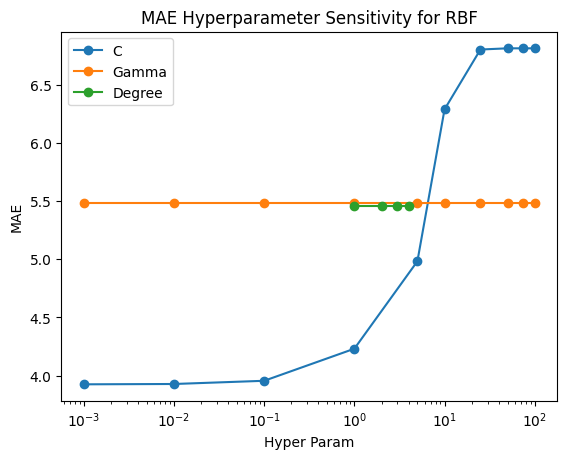

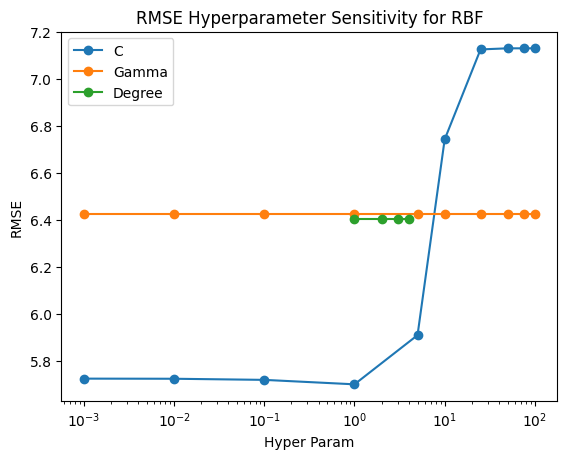

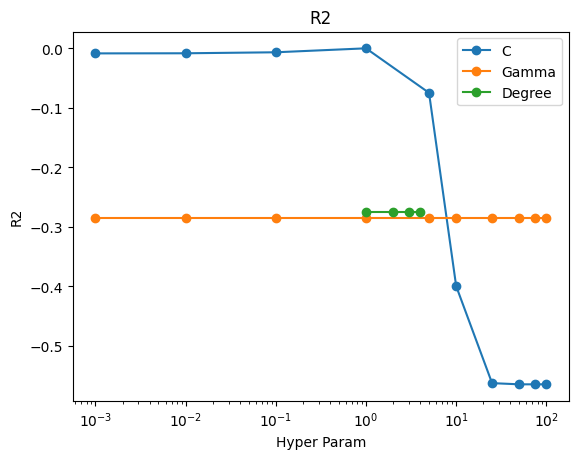

In [77]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
#y variable is just the metric, for the x just choose the degree or the c value, and within each of them you plot multiple each of them representing a different degree
rbf_res = kernels_df[kernels_df['kernel'] == 'rbf']
rbf_numeric_gamma = rbf_res[(rbf_res['Gamma'] != 'auto') & (rbf_res['Gamma'] != 'scale')]

fig, ax = plt.subplots()
ax.plot(rbf_res.groupby('C')["MAE"].mean(), marker='o', label='C')
ax.plot(rbf_numeric_gamma.groupby('Gamma')['MAE'].mean(), marker='o', label='Gamma')
ax.plot(rbf_res.groupby('Degree')["MAE"].mean(), marker='o', label='Degree')
ax.set_xlabel('Hyper Param')
ax.set_ylabel('MAE')
ax.set_title('MAE Hyperparameter Sensitivity for RBF')
ax.set_xticks([0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100])
ax.set_xscale('log')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(rbf_res.groupby('C')["RMSE"].mean(), marker='o', label='C')
ax.plot(rbf_numeric_gamma.groupby('Gamma')['RMSE'].mean(), marker='o', label='Gamma')
ax.plot(rbf_res.groupby('Degree')["RMSE"].mean(), marker='o', label='Degree')
ax.set_xlabel('Hyper Param')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Hyperparameter Sensitivity for RBF')
ax.set_xticks([0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100])
ax.set_xscale('log')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(rbf_res.groupby('C')["R2"].mean(), marker='o', label='C')
ax.plot(rbf_numeric_gamma.groupby('Gamma')['R2'].mean(), marker='o', label='Gamma')
ax.plot(rbf_res.groupby('Degree')["R2"].mean(), marker='o', label='Degree')
ax.set_xlabel('Hyper Param')
ax.set_ylabel('R2')
ax.set_title('R2')
ax.set_xticks([0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 75, 100])
ax.set_xscale('log')
ax.legend()
plt.show()
                                                                                             